# Korrelation – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/korrelation)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **Korrelation** misst die Stärke und Richtung des **linearen Zusammenhangs**
zwischen zwei Variablen. Der Korrelationskoeffizient r liegt zwischen −1 und +1.

**Kovarianz (Grundlage):**
$$\text{Cov}(X,Y) = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

**Pearson-Korrelationskoeffizient:**
$$r = \frac{\text{Cov}(X,Y)}{s_X \cdot s_Y} = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

**Signifikanztest (t-Test auf r):**
$$t = r \cdot \sqrt{\frac{n-2}{1-r^2}}, \quad df = n-2$$

**Stärke des Zusammenhangs (numiqo / Kuckartz et al.):**

| |r| | Stärke |
|---|---|
| 0,0 – 0,1 | Kein Zusammenhang |
| 0,1 – 0,3 | Geringer Zusammenhang |
| 0,3 – 0,5 | Mittlerer Zusammenhang |
| 0,5 – 0,7 | Hoher Zusammenhang |
| 0,7 – 1,0 | Sehr hoher Zusammenhang |

**Korrelationsarten im Überblick:**

| Methode | Skalenniveau | Voraussetzung |
|---|---|---|
| **Pearson** | Metrisch | Normalverteilung, linearer Zusammenhang |
| **Spearman** | Ordinal / Metrisch | Keine NV nötig (nichtparametrisch) |
| **Punktbiserial** | Eine metrisch, eine dichotom | Wie Pearson |

> **Wichtig:** Korrelation ≠ Kausalität!

In [19]:
print("Kernel läuft")

Kernel läuft


In [20]:
import matplotlib
matplotlib.use("Agg")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# matplotlib rendert di ePlots direkt im Notebook ohne plt.show()
%matplotlib inline

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Positive, negative und keine Korrelation

Der Korrelationskoeffizient r zeigt Richtung und Stärke des Zusammenhangs.

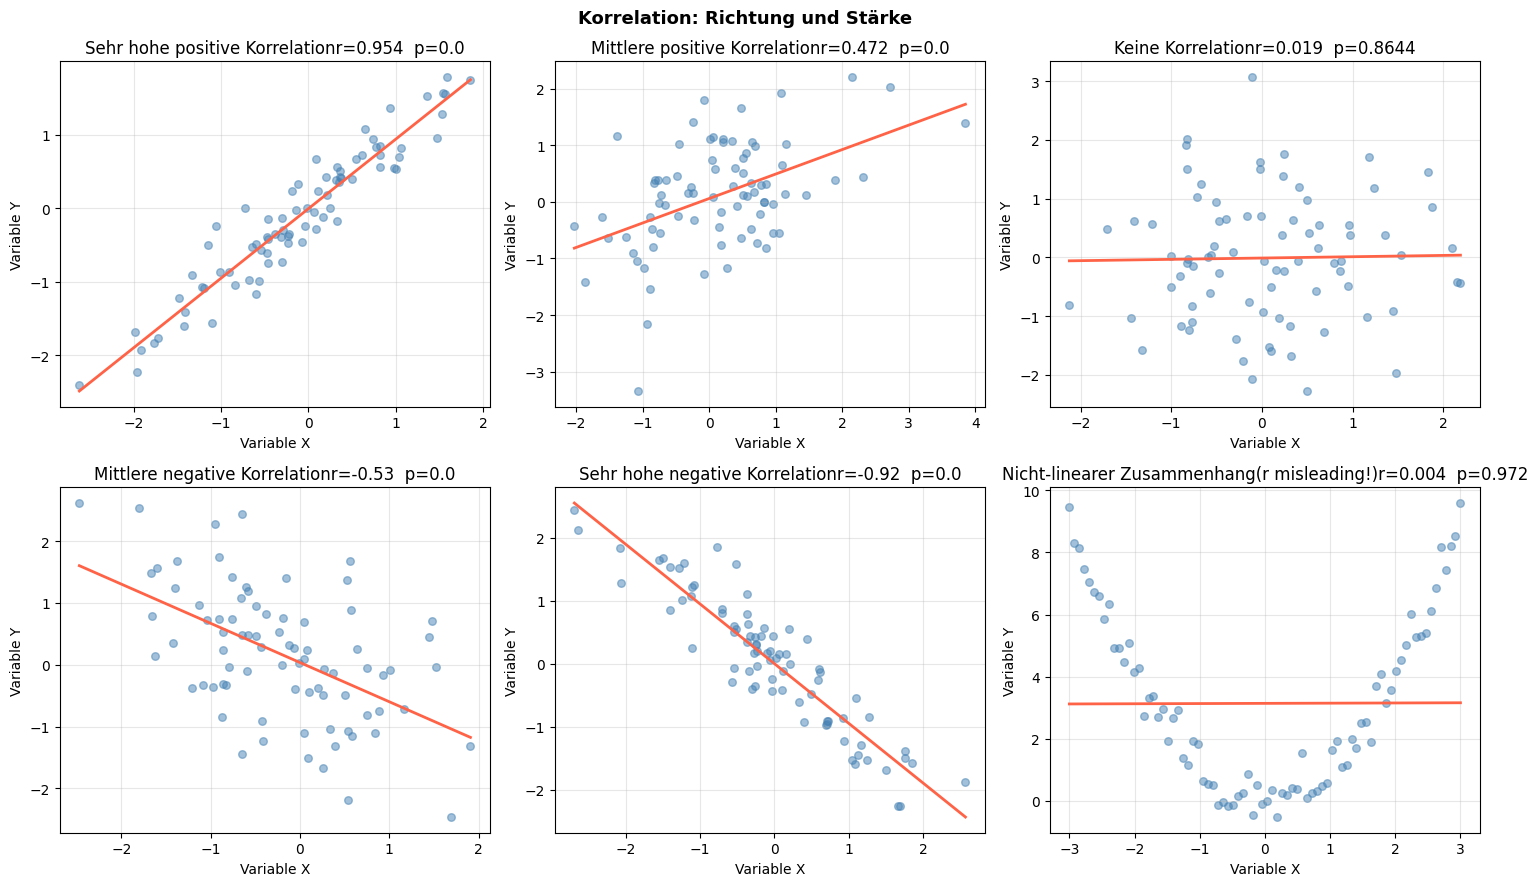

In [21]:
# Verschiedene Korrelationsstärken visualisieren
np.random.seed(42)
n_v = 80

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Korrelation: Richtung und Stärke", fontsize=13, fontweight="bold")

szenarien = [
    (0.95,  "Sehr hohe positive Korrelation"),
    (0.50,  "Mittlere positive Korrelation"),
    (0.05,  "Keine Korrelation"),
    (-0.50, "Mittlere negative Korrelation"),
    (-0.90, "Sehr hohe negative Korrelation"),
    (0.75,  "Nicht-linearer Zusammenhang(r misleading!)"),
]

for ax, (r_ziel, titel) in zip(axes.flat, szenarien):
    if "Nicht-linear" in titel:
        x = np.linspace(-3, 3, n_v)
        y = x**2 + np.random.normal(0, 0.5, n_v)
    else:
        x = np.random.normal(0, 1, n_v)
        y = r_ziel * x + np.sqrt(1 - r_ziel**2) * np.random.normal(0, 1, n_v)

    r_ber, p_ber = pearsonr(x, y)

    ax.scatter(x, y, alpha=0.5, color="steelblue", s=30)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m*x_line + b, color="tomato", linewidth=2)
    ax.set_title(titel + "r=" + str(round(r_ber, 3)) +
                 "  p=" + str(round(p_ber, 4)))
    ax.set_xlabel("Variable X")
    ax.set_ylabel("Variable Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Das numiqo-Beispiel: Körpergröße und Gewicht

**Fragestellung:** Gibt es einen Zusammenhang zwischen Körpergröße und Gewicht?

**Datensatz (n = 10):**

| Körpergröße (m) | 1,62 | 1,72 | 1,85 | 1,82 | 1,72 | 1,55 | 1,65 | 1,77 | 1,83 | 1,53 |
|---|---|---|---|---|---|---|---|---|---|---|
| **Gewicht (kg)** | 53 | 71 | 85 | 86 | 76 | 62 | 68 | 77 | 97 | 65 |

**Erwartetes numiqo-Ergebnis:** r(8) = 0,86, p = 0,001 → **signifikant, sehr hoher Zusammenhang**

In [22]:
# numiqo-Datensatz
groesse = np.array([1.62, 1.72, 1.85, 1.82, 1.72, 1.55, 1.65, 1.77, 1.83, 1.53])
gewicht = np.array([53,   71,   85,   86,   76,   62,   68,   77,   97,   65])
n = len(groesse)

print("Deskriptive Statistiken")
print("Körpergrößee: MW=" + str(round(groesse.mean(), 3)) +
      "  SD=" + str(round(groesse.std(ddof=1), 3)))
print("Gewicht:        MW=" + str(round(gewicht.mean(), 2)) +
      "  SD=" + str(round(gewicht.std(ddof=1), 2)))
print()

# Pearson manuell
x_c = groesse - groesse.mean()
y_c = gewicht - gewicht.mean()
cov_xy = (x_c * y_c).sum() / (n-1)
r_man  = cov_xy / (groesse.std(ddof=1) * gewicht.std(ddof=1))
t_man  = r_man * np.sqrt((n-2) / (1 - r_man**2))
p_man  = 2 * stats.t.sf(abs(t_man), df=n-2)

print("Pearson-Korrelation (manuell)")
print("Kovarianz:    " + str(round(cov_xy, 6)))
print("r:            " + str(round(r_man, 4)) + "  (numiqo: 0,86)")
print("t(" + str(n-2) + "):       " + str(round(t_man, 4)))
print("p:            " + str(round(p_man, 4)) + "  (numiqo: 0,001)")
print()

# scipy Kontrolle
r_sci, p_sci = pearsonr(groesse, gewicht)
print("Kontrolle scipy: r=" + str(round(r_sci, 4)) + "  p=" + str(round(p_sci, 4)))
print()

def interpret_r(r):
    ar = abs(r)
    if ar < 0.1: return "kein Zusammenhang"
    elif ar < 0.3: return "geringer Zusammenhang"
    elif ar < 0.5: return "mittlerer Zusammenhang"
    elif ar < 0.7: return "hoher Zusammenhang"
    return "sehr hoher Zusammenhang"

print("Interpretation: r=" + str(round(r_sci, 3)) + " -> " + interpret_r(r_sci))
print()
if p_sci < 0.05:
    print("p=" + str(round(p_sci, 4)) + " < 0.05 -> signifikanter Zusammenhang!")
    print("APA: r(8) = 0.86, p = .001")
else:
    print("p=" + str(round(p_sci, 4)) + " >= 0.05 -> nicht signifikant")

Deskriptive Statistiken
Körpergrößee: MW=1.706  SD=0.115
Gewicht:        MW=74.0  SD=12.99

Pearson-Korrelation (manuell)
Kovarianz:    1.286667
r:            0.86  (numiqo: 0,86)
t(8):       4.7667
p:            0.0014  (numiqo: 0,001)

Kontrolle scipy: r=0.86  p=0.0014

Interpretation: r=0.86 -> sehr hoher Zusammenhang

p=0.0014 < 0.05 -> signifikanter Zusammenhang!
APA: r(8) = 0.86, p = .001


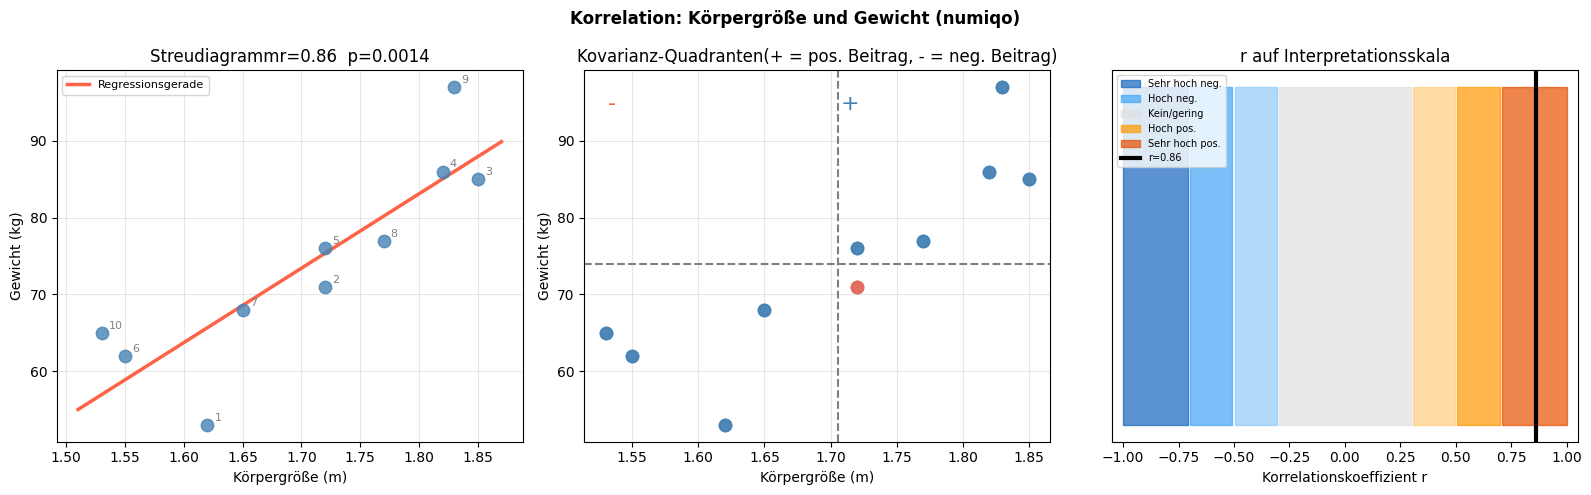

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Korrelation: Körpergröße und Gewicht (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Streudiagramm mit Regressionsgerade
axes[0].scatter(groesse, gewicht, color="steelblue", s=80, alpha=0.8, zorder=3)
m_r, b_r = np.polyfit(groesse, gewicht, 1)
x_l = np.linspace(groesse.min()-0.02, groesse.max()+0.02, 100)
axes[0].plot(x_l, m_r*x_l + b_r, color="tomato", linewidth=2.5,
             label="Regressionsgerade")
for i, (g, w) in enumerate(zip(groesse, gewicht)):
    axes[0].annotate(str(i+1), (g, w), textcoords="offset points",
                     xytext=(5, 3), fontsize=8, color="gray")
axes[0].set_title("Streudiagrammr=" + str(round(r_sci, 3)) +
                  "  p=" + str(round(p_sci, 4)))
axes[0].set_xlabel("Körpergröße (m)")
axes[0].set_ylabel("Gewicht (kg)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Kovarianz visuell (Quadranten)
axes[1].scatter(groesse, gewicht, color="steelblue", s=80, alpha=0.8, zorder=3)
axes[1].axvline(groesse.mean(), color="gray", linestyle="--", linewidth=1.5)
axes[1].axhline(gewicht.mean(), color="gray", linestyle="--", linewidth=1.5)
axes[1].set_title("Kovarianz-Quadranten(+ = pos. Beitrag, - = neg. Beitrag)")
axes[1].set_xlabel("Körpergröße (m)")
axes[1].set_ylabel("Gewicht (kg)")
for g, w in zip(groesse, gewicht):
    fc = "steelblue" if (g - groesse.mean()) * (w - gewicht.mean()) > 0 else "tomato"
    axes[1].scatter(g, w, color=fc, s=80, alpha=0.8, zorder=3)
axes[1].text(groesse.mean()+0.002, gewicht.max()-3, "+", fontsize=16, color="steelblue")
axes[1].text(groesse.min()+0.002, gewicht.max()-3, "-", fontsize=16, color="tomato")
axes[1].grid(alpha=0.3)

# 3. Korrelationsköffizient als Skala
r_werte = np.linspace(-1, 1, 200)
axes[2].fill_between(r_werte[r_werte < -0.7], 0, 1, color="#1565C0", alpha=0.7,
                     label="Sehr hoch neg.")
axes[2].fill_between(r_werte[(r_werte >= -0.7) & (r_werte < -0.5)], 0, 1,
                     color="#42A5F5", alpha=0.7, label="Hoch neg.")
axes[2].fill_between(r_werte[(r_werte >= -0.5) & (r_werte < -0.3)], 0, 1,
                     color="#90CAF9", alpha=0.7)
axes[2].fill_between(r_werte[(r_werte >= -0.3) & (r_werte < 0.3)], 0, 1,
                     color="#E0E0E0", alpha=0.7, label="Kein/gering")
axes[2].fill_between(r_werte[(r_werte >= 0.3) & (r_werte < 0.5)], 0, 1,
                     color="#FFCC80", alpha=0.7)
axes[2].fill_between(r_werte[(r_werte >= 0.5) & (r_werte < 0.7)], 0, 1,
                     color="#FF9800", alpha=0.7, label="Hoch pos.")
axes[2].fill_between(r_werte[r_werte >= 0.7], 0, 1,
                     color="#E65100", alpha=0.7, label="Sehr hoch pos.")
axes[2].axvline(r_sci, color="black", linewidth=3,
                label="r=" + str(round(r_sci, 2)))
axes[2].set_title("r auf Interpretationsskala")
axes[2].set_xlabel("Korrelationskoeffizient r")
axes[2].set_yticks([])
axes[2].legend(fontsize=7, loc="upper left")
axes[2].set_xlim(-1.05, 1.05)

plt.tight_layout()
plt.show()

## 3. Schritt-für-Schritt-Berechnung

1. Mittelwerte $\bar{x}$, $\bar{y}$ berechnen
2. Abweichungen $(x_i - \bar{x})$ und $(y_i - \bar{y})$
3. Kovarianz: $\sum (x_i-\bar{x})(y_i-\bar{y}) / (n-1)$
4. $r = \text{Cov}(X,Y) / (s_X \cdot s_Y)$
5. t-Test: $t = r \cdot \sqrt{(n-2)/(1-r^2)}$, $df = n-2$

In [24]:
print("Schritt-für-Schritt: Körpergröße-Gewicht")
print()
print("Schritt 1: Mittelwerte")
print("  x_bar = " + str(round(groesse.mean(), 4)))
print("  y_bar = " + str(round(gewicht.mean(), 4)))
print()
print("Schritt 2: Abweichungen und Produkte")
print("i   x       y     x-x_bar  y-y_bar  Produkt")
sum_prod = 0
sum_x2 = 0
sum_y2 = 0
for i, (g, w) in enumerate(zip(groesse, gewicht)):
    xc = g - groesse.mean()
    yc = w - gewicht.mean()
    prod = xc * yc
    sum_prod += prod
    sum_x2 += xc**2
    sum_y2 += yc**2
    print(str(i+1) + "  " + str(g) + "  " + str(w) + "  " +
          str(round(xc, 4)) + "  " + str(round(yc, 2)) + "  " +
          str(round(prod, 4)))
print()
print("Schritt 3: Kovarianz = " + str(round(sum_prod, 4)) +
      " / " + str(n-1) + " = " + str(round(sum_prod/(n-1), 6)))
print()
print("Schritt 4: r = Cov / (s_x * s_y) = " +
      str(round(sum_prod/(n-1), 6)) + " / (" +
      str(round(groesse.std(ddof=1), 4)) + " * " +
      str(round(gewicht.std(ddof=1), 4)) + ")")
print("  r = " + str(round(r_man, 4)))
print()
print("Schritt 5: t = " + str(round(t_man, 4)) +
      ", df=" + str(n-2) + ", p=" + str(round(p_man, 4)))

Schritt-für-Schritt: Körpergröße-Gewicht

Schritt 1: Mittelwerte
  x_bar = 1.706
  y_bar = 74.0

Schritt 2: Abweichungen und Produkte
i   x       y     x-x_bar  y-y_bar  Produkt
1  1.62  53  -0.086  -21.0  1.806
2  1.72  71  0.014  -3.0  -0.042
3  1.85  85  0.144  11.0  1.584
4  1.82  86  0.114  12.0  1.368
5  1.72  76  0.014  2.0  0.028
6  1.55  62  -0.156  -12.0  1.872
7  1.65  68  -0.056  -6.0  0.336
8  1.77  77  0.064  3.0  0.192
9  1.83  97  0.124  23.0  2.852
10  1.53  65  -0.176  -9.0  1.584

Schritt 3: Kovarianz = 11.58 / 9 = 1.286667

Schritt 4: r = Cov / (s_x * s_y) = 1.286667 / (0.1152 * 12.9872)
  r = 0.86

Schritt 5: t = 4.7667, df=8, p=0.0014


## 4. Korrelation ≠ Kausalität

Eine hohe Korrelation bedeutet **nicht**, dass eine Variable die andere verursacht.

**Beispiele für Scheinkorrelationen:**
- Eisverkauf korreliert mit Ertrinkungsunfällen (Drittvariable: Hitze)
- Schuhgröße korreliert mit Lesefähigkeit bei Kindern (Drittvariable: Alter)
- Anzahl Störche korreliert mit Geburtenrate (Drittvariable: Ländlichkeit)

> Aufgedeckte Korrelationen sollten **nie sofort inhaltlich** interpretiert werden –
> immer auf mögliche Drittvariablen achten! → Partialkorrelation

Scheinkorrelation: Eisverkauf und Ertrinkungsfälle
r(Eis, Ertrinkungen)   = 0.721 -> sehr hoher Zusammenhang
r(Temp, Eis)           = 0.965
r(Temp, Ertrinkungen)  = 0.784

-> Eis und Ertrinkungen korrelieren NICHT kausal!
   Drittvariable 'Temperatur' erklärt beide Anstiege!


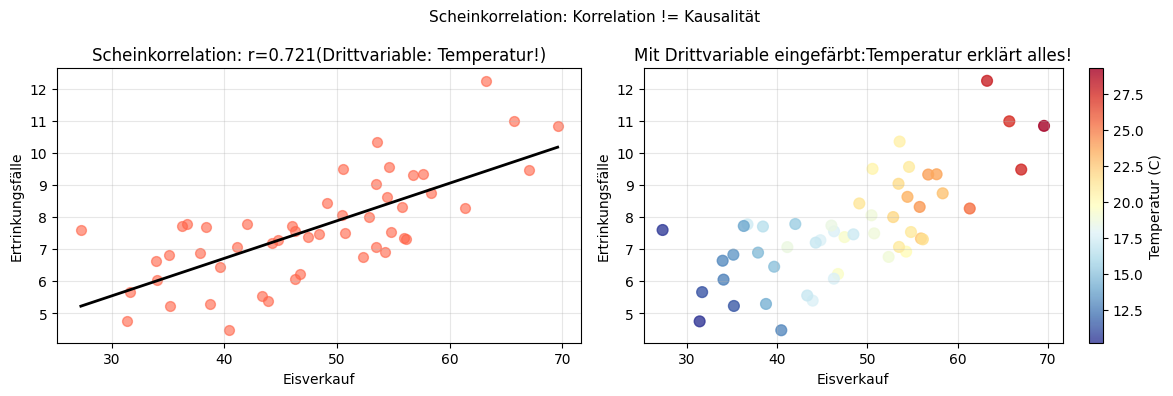

In [25]:
# Scheinkorrelation demonstrieren
np.random.seed(42)
n_sc = 50
# Drittvariable: Temperatur
temperatur = np.random.normal(20, 5, n_sc)
eisverkauf    = 10 + 2 * temperatur + np.random.normal(0, 3, n_sc)
ertrinkungen  = 2  + 0.3 * temperatur + np.random.normal(0, 1, n_sc)

r_eis, p_eis = pearsonr(eisverkauf, ertrinkungen)
r_temp_eis, _ = pearsonr(temperatur, eisverkauf)
r_temp_ert, _ = pearsonr(temperatur, ertrinkungen)

print("Scheinkorrelation: Eisverkauf und Ertrinkungsfälle")
print("r(Eis, Ertrinkungen)   = " + str(round(r_eis, 3)) +
      " -> " + interpret_r(r_eis))
print("r(Temp, Eis)           = " + str(round(r_temp_eis, 3)))
print("r(Temp, Ertrinkungen)  = " + str(round(r_temp_ert, 3)))
print()
print("-> Eis und Ertrinkungen korrelieren NICHT kausal!")
print("   Drittvariable 'Temperatur' erklärt beide Anstiege!")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Scheinkorrelation: Korrelation != Kausalität", fontsize=11)

axes[0].scatter(eisverkauf, ertrinkungen, color="tomato", alpha=0.6, s=50)
m0, b0 = np.polyfit(eisverkauf, ertrinkungen, 1)
x0 = np.linspace(eisverkauf.min(), eisverkauf.max(), 100)
axes[0].plot(x0, m0*x0 + b0, color="black", linewidth=2)
axes[0].set_title("Scheinkorrelation: r=" + str(round(r_eis, 3)) +
                  "(Drittvariable: Temperatur!)")
axes[0].set_xlabel("Eisverkauf")
axes[0].set_ylabel("Ertrinkungsfälle")
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(eisverkauf, ertrinkungen,
                     c=temperatur, cmap="RdYlBu_r", s=60, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label="Temperatur (C)")
axes[1].set_title("Mit Drittvariable eingefärbt:Temperatur erklärt alles!")
axes[1].set_xlabel("Eisverkauf")
axes[1].set_ylabel("Ertrinkungsfälle")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Pearson vs. Spearman

| | Pearson | Spearman |
|---|---|---|
| **Typ** | Parametrisch | Nichtparametrisch |
| **Skalenniveau** | Metrisch | Ordinal oder metrisch |
| **NV nötig?** | Ja | Nein |
| **Misst** | Linearen Zusammenhang | Monotonen Zusammenhang |
| **Basis** | Rohdaten | Ränge |

Ohne Ausreisser:
  Pearson  r=0.99  p=0.0
  Spearman r=0.9895  p=0.0

Mit Ausreisser:
  Pearson  r=0.4517  p=0.0398
  Spearman r=0.8243  p=0.0



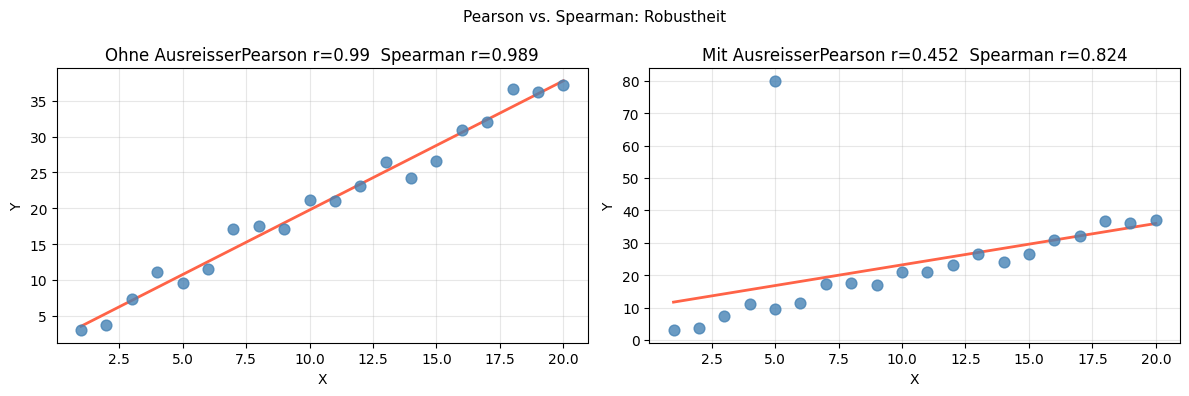

In [26]:
# Pearson vs. Spearman: Ausreisser-Effekt
np.random.seed(42)
n_ps = 20
x_ps = np.arange(1, n_ps+1, dtype=float)
y_ps = 2 * x_ps + np.random.normal(0, 2, n_ps)

# Mit Ausreisser
x_out = np.append(x_ps, [5])
y_out = np.append(y_ps, [80])  # starker Ausreisser

for daten, titel in [(np.column_stack([x_ps, y_ps]), "Ohne Ausreisser"),
                      (np.column_stack([x_out, y_out]), "Mit Ausreisser")]:
    xd, yd = daten[:, 0], daten[:, 1]
    rp, pp = pearsonr(xd, yd)
    rs, ps = spearmanr(xd, yd)
    print(titel + ":")
    print("  Pearson  r=" + str(round(rp, 4)) + "  p=" + str(round(pp, 4)))
    print("  Spearman r=" + str(round(rs, 4)) + "  p=" + str(round(ps, 4)))
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Pearson vs. Spearman: Robustheit", fontsize=11)

for ax, (xd, yd, titel) in zip(axes, [
    (x_ps, y_ps, "Ohne Ausreisser"),
    (x_out, y_out, "Mit Ausreisser")
]):
    rp2, pp2 = pearsonr(xd, yd)
    rs2, ps2 = spearmanr(xd, yd)
    ax.scatter(xd, yd, color="steelblue", s=60, alpha=0.8, zorder=3)
    m2, b2 = np.polyfit(xd, yd, 1)
    xl2 = np.linspace(xd.min(), xd.max(), 100)
    ax.plot(xl2, m2*xl2 + b2, color="tomato", linewidth=2)
    ax.set_title(titel + "Pearson r=" + str(round(rp2, 3)) +
                 "  Spearman r=" + str(round(rs2, 3)))
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# APA-Ausgabe-Funktion
def korrelation_apa(x, y, var_x="Variable X", var_y="Variable Y",
                    methode="pearson", alpha=0.05):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n_f  = len(x)

    if methode == "pearson":
        r_f, p_f = pearsonr(x, y)
        name_m   = "Pearson"
        df_f     = n_f - 2
    else:
        r_f, p_f = spearmanr(x, y)
        name_m   = "Spearman"
        df_f     = n_f - 2

    interp = interpret_r(r_f)
    richtg = "positiv" if r_f > 0 else "negativ"
    sig_txt = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str  = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print(name_m + "-Korrelation: " + var_x + " x " + var_y)
    print("n=" + str(n_f) + "  r=" + str(round(r_f, 4)) + "  " + p_str)
    print("Zusammenhang: " + interp + " (" + richtg + ")")
    print("Ergebnis: " + sig_txt)
    print()
    if p_f < alpha:
        print("APA: r(" + str(df_f) + ") = " + str(round(r_f, 2)) +
              ", " + p_str)
    print()

# numiqo-Hauptbeispiel
korrelation_apa(groesse, gewicht, "Körpergröße", "Gewicht", "pearson")
print()
# Spearman auf denselben Daten
korrelation_apa(groesse, gewicht, "Körpergröße", "Gewicht", "spearman")

Pearson-Korrelation: Körpergröße x Gewicht
n=10  r=0.86  p = .001
Zusammenhang: sehr hoher Zusammenhang (positiv)
Ergebnis: signifikant

APA: r(8) = 0.86, p = .001


Spearman-Korrelation: Körpergröße x Gewicht
n=10  r=0.9119  p < .001
Zusammenhang: sehr hoher Zusammenhang (positiv)
Ergebnis: signifikant

APA: r(8) = 0.91, p < .001



## 6. Zusammenfassung

```
Korrelation – Übersicht
│
├── WAS?
│   Mass für Richtung und Stärke des linearen Zusammenhangs
│   r in [-1, +1]: +1=perfekt positiv, -1=perfekt negativ, 0=kein
│
├── DREI VARIANTEN
│   Pearson:        metrisch, NV gegeben, linearer Zshg.
│   Spearman:       ordinal / metrisch, kein NV nötig
│   Punktbiserial:  eine metrisch + eine dichotom (= Pearson)
│
├── BERECHNUNG (Pearson)
│   Cov(X,Y) = Sum[(x-x_bar)(y-y_bar)] / (n-1)
│   r = Cov / (s_x * s_y)
│   t = r * sqrt((n-2)/(1-r^2))  -> p aus t-Verteilung, df=n-2
│
├── STÄRKE-INTERPRETATION (numiqo / Kuckartz 2013)
│   |r| < 0.1:  kein Zusammenhang
│   0.1 - 0.3:  gering
│   0.3 - 0.5:  mittel
│   0.5 - 0.7:  hoch
│   0.7 - 1.0:  sehr hoch
│
├── WICHTIG: KORRELATION != KAUSALITÄT!
│   Drittvariablen können Scheinkorrelationen erzeugen
│   -> Partialkorrelation zur Kontrolle
│
├── numiqo-BEISPIEL: Körpergröße & Gewicht
│   r(8) = 0.86, p = .001 -> sehr hoher positiver Zusammenhang
│
└── PYTHON
    from scipy.stats import pearsonr, spearmanr
    r, p = pearsonr(x, y)
    r, p = spearmanr(x, y)
```

---
Quelle: [numiqo.de/tutorial/korrelation](https://numiqo.de/tutorial/korrelation)